 8. We will now perform cross-validation on a simulated data set.
 (a) Generate a simulated data set as follows:
 rng = np.random.default_rng(1)
 x = rng.normal(size=100)
 y = x- 2 * x**2 + rng.normal(size=100)
 In this data set, what is n and what is p? Write out the model
 used to generate the data in equation form.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
import scipy
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
np.random.seed(1)
X = np.sort(np.random.randn(100))
y = X - 2 * X**2 + np.random.randn(100)

$$ y = X - 2X^2 + \epsilon $$

- n = 100
- p = 2

(b) Create a scatterplot of X against Y . Comment on what you find.

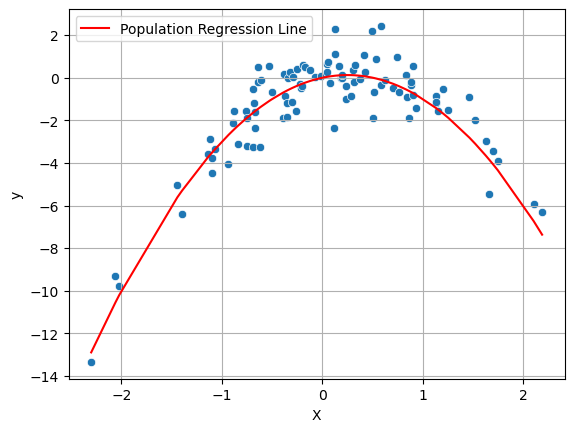

In [3]:
ax = sns.scatterplot(x=X, y=y)
ax.plot(X, X-2*X**2, color='r', label='Population Regression Line')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.grid()
ax.legend()

This scatter plot shows observed data points along with a population regression curve. The regression line is non-linear , specifically a quadratic curve , which suggests a curved relationship between X and y.y increases as X moves from negative values ​​towards 0. y decreases again as X becomes more positive.

(c) Set a random seed, and then compute the LOOCV errors that
 result from fitting the following four models using least squares:
 i. Y =β0+β1X +ϵ
 ii. Y = β0 +β1X +β2X2+ϵ
 iii. Y = β0 +β1X +β2X2 +β3X3+ϵ
 iv. Y = β0 +β1X +β2X2+β3X3+β4X4+ϵ.
 Note you may find it helpful to use the data.frame() function
 to create a single data set containing both X and Y .

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

def poly_loocv(data, degree):
    
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    lm = LinearRegression()
    
    cv_score = cross_val_score(lm, poly.fit_transform(data['x'][:, np.newaxis]), data['y'],
                                     scoring='neg_mean_squared_error', cv=len(data['x']))
    
    return -np.mean(cv_score)

In [5]:
df = pd.DataFrame({ 'y': y, 'x': X })

In [7]:
def poly_loocv(data, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    lm = LinearRegression()

    # ✅ Make X explicitly 2D
    X = data['x'].to_numpy().reshape(-1, 1)   # or: data[['x']].to_numpy()
    y = data['y']                             # y can stay as a Series

    X_poly = poly.fit_transform(X)

    cv_score = cross_val_score(
        lm,
        X_poly,
        y,
        scoring='neg_mean_squared_error',
        cv=len(data['x'])   # LOOCV
    )

    return -np.mean(cv_score)

In [8]:
np.random.seed(10)
loocv_results = [poly_loocv(df, deg) for deg in range(1, 5)]
loocv_results

[np.float64(5.90663789467059),
 np.float64(0.8889974749237378),
 np.float64(0.907849666352407),
 np.float64(0.9334254546612126)]

Text(0.5, 0, 'Polynomial Order')

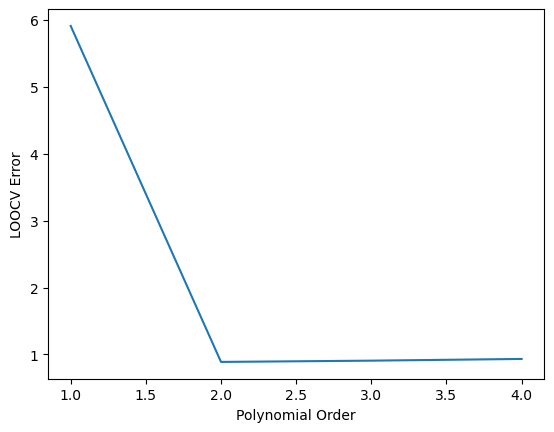

In [9]:
plt.plot(range(1,5), loocv_results)
plt.ylabel('LOOCV Error')
plt.xlabel('Polynomial Order')

 (d) Repeat (c) using another random seed, and report your results.
 Are your results the same as what you got in (c)? Why?

In [10]:
np.random.seed(405)
loocv_results = [poly_loocv(df, deg) for deg in range(1, 5)]
loocv_results

[np.float64(5.90663789467059),
 np.float64(0.8889974749237378),
 np.float64(0.907849666352407),
 np.float64(0.9334254546612126)]

Text(0.5, 0, 'Polynomial Order')

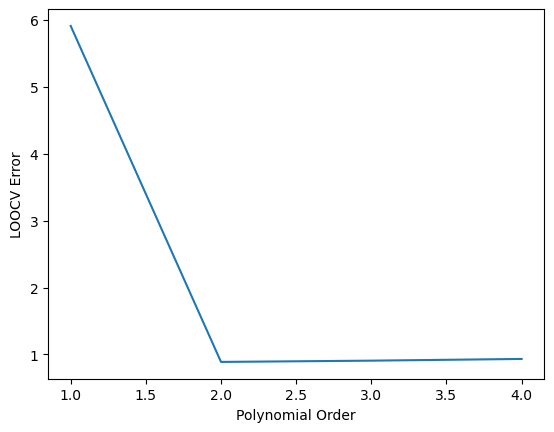

In [11]:
plt.plot(range(1,5), loocv_results)
plt.ylabel('LOOCV Error')
plt.xlabel('Polynomial Order')

We get the same results. This is because LOOCV does not involve any randomness. Unlike other cross-validation methods, there is only one way to calculate the LOOCV error: 

- Leave one observation out as the test set
- Train the model on the remaining set (the training set)
- Evaluate the model on the test set
- Repeat this process n times, until each observation has been used as a test set once
- Average these n errors to obtain the test error estimate.

In [ ]:
(e) Which of the models in (c) had the smallest LOOCV error? Is
 this what you expected? Explain your answer.

The LOOCV analysis reveals that the second order polynomial has the smallest error. This finding is consistent with our previous observations in section (a), where we identified that the model has 2 roots and one maximum point at 0.25. Therefore, we would expect a quadratic relationship between X and y, which is confirmed by the LOOCV analysis.

 (f) Comment on the statistical significance of the coefficient esti
mates that results from fitting each of the models in (c) using
 least squares. Do these results agree with the conclusions drawn
 based on the cross-validation results?

In [12]:
df['x_2'] = X**2
df['x_3'] = X**3
df['x_4'] = X**4
df.head()

,y,x,x_2,x_3,x_4
0,-13.342828,-2.301539,5.297080,-12.191435,28.059060
1,-9.323992,-2.060141,4.244180,-8.743607,18.013062
2,-9.797305,-2.022201,4.089298,-8.269383,16.722356
3,-5.021465,-1.444114,2.085465,-3.011648,4.349163
4,-6.391812,-1.396496,1.950202,-2.723450,3.803288


In [13]:
def stat_significance(df, degree):
    X = sm.add_constant(df.loc[:, ['x', 'x_2', 'x_3', 'x_4']])
    y = df['y']
    
    lm = sm.OLS(y, X.loc[:, 'const':f'x_{degree}']).fit()
    print(f'Degree: {degree}')
    print(lm.summary().tables[1])
    print('')

In [14]:
for i in range(1, 5):
    stat_significance(df, i)

Degree: 1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4165      0.234     -6.048      0.000      -1.881      -0.952
x              0.9171      0.264      3.474      0.001       0.393       1.441

Degree: 2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0787      0.114      0.689      0.492      -0.148       0.305
x              1.1417      0.106     10.799      0.000       0.932       1.352
x_2           -1.9167      0.084    -22.787      0.000      -2.084      -1.750

Degree: 3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0792      0.115      0.689      0.492      -0.149       0.307
x              1.154